#Spatial Inequality in Access to Community Health Clinics Across Chicago

##Introduction

Chicago has long experienced major inequalities in healthcare access that are closely tied to patterns of segregation, income inequality, and uneven urban development. Community health clinics, particularly Federally Qualified Health Centers (FQHCs), play an important role in providing affordable primary care services to underserved populations, including low-income residents, uninsured individuals, immigrants, refugees, and youth. Understanding where these clinics are located can provide insight into how healthcare resources are distributed across the city and whether certain neighborhoods may still face barriers to access.

This project uses geospatial analysis to examine the distribution of community health clinics across Chicago community areas. Using clinic location data containing addresses, geographic coordinates, and clinic classifications, a spatial dataset was created and mapped using GeoPandas. The project investigates whether clinics appear evenly distributed throughout the city or whether they cluster in particular neighborhoods and corridors.


In [96]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from census import Census
from us import states
from shapely.geometry import Point

clinics = pd.read_csv("/content/Clinics.csv")

In [97]:
clinics.columns = [
    "clinic_name",
    "community_area",
    "phone",
    "clinic_notes",
    "address_raw"
]
clinics["community_area_num"] = clinics["community_area"].str.extract(r"\((\d+)\)")
clinics["community_area_name"] = clinics["community_area"].str.extract(r"^(.*?)\s*\(")
clinics["latitude"] = clinics["address_raw"].str.extract(r"\(([-\d\.]+),")
clinics["longitude"] = clinics["address_raw"].str.extract(r",\s*([-\d\.]+)\)")
clinics["latitude"] = pd.to_numeric(clinics["latitude"], errors="coerce")
clinics["longitude"] = pd.to_numeric(clinics["longitude"], errors="coerce")
clinics["zip"] = clinics["address_raw"].str.extract(r"(\d{5})")
clinics["address"] = (
    clinics["address_raw"]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.replace(r"\d{5}", "", regex=True)
    .str.replace(r"\n", " ", regex=True)
    .str.strip()
)

def classify_clinic(x):
    x = str(x).lower()

    if "fqhc" in x:
        return "FQHC"
    elif "look-alike" in x:
        return "Look-alike"
    else:
        return "Other"

clinics["clinic_type"] = clinics["clinic_notes"].apply(classify_clinic)

clinics = clinics.drop_duplicates()
clinics.to_csv("clinics.csv", index=False)

In [98]:
clinics

,clinic_name,community_area,phone,clinic_notes,address_raw,community_area_num,community_area_name,latitude,longitude,zip,address,clinic_type
0,Mercy Family Health Center @ Oakwood Shores,OAKLAND (36),(773) 451-0460,Look-alike,3753 S. Cottage Grove60653\n(41.82672248000045...,36,OAKLAND,41.826722,-87.608287,60653,3753 S. Cottage Grove,Look-alike
1,ACCESS Southwest Family Health Center,GARFIELD RIDGE (56),(866) 882-2237,FQHC,"4839 W. 47th Street60638\n(41.80757461200045, ...",56,GARFIELD RIDGE,41.807575,-87.744602,60638,4839 W. 47th Street,FQHC
2,Heartland Health Outreach- Refugee Health,UPTOWN (3),(773) 751-1744,FQHC; specialize in refugee health,"4750 N Sheridan Rd60640\n(41.96843068300046, -...",3,UPTOWN,41.968431,-87.654857,60640,4750 N Sheridan Rd,FQHC
3,Heartland Health Center- Hibbard Elementary Sc...,ALBANY PARK (14),(773) 336-6100,FQHC; School-based health center (open to comm...,4930 North Sawyer Avenue60625\n(41.97084703000...,14,ALBANY PARK,41.970847,-87.709774,60625,4930 North Sawyer Avenue,FQHC
4,Near North - Winfield Moody Health Center,NEAR NORTH SIDE (8),(312) 337-1073,FQHC,"1276 N. Clybourn60610\n(41.90535451700049, -87...",8,NEAR NORTH SIDE,41.905355,-87.641786,60610,1276 N. Clybourn,FQHC
...,...,...,...,...,...,...,...,...,...,...,...,...
115,Mercy Family Health Center @ Mercy Hospital,NEAR SOUTH SIDE (33),(312) 567-2000,Look-alike,"2525 S. Michigan60616\n(41.846811956000465, -8...",33,NEAR SOUTH SIDE,41.846812,-87.623523,60616,2525 S. Michigan,Look-alike
116,ACCESS Cabrini Family Health Center,MCKINLEY PARK (59),(866) 882-2237,FQHC,"3450 S. Archer Ave.60608\n(41.8312221810005, -...",59,MCKINLEY PARK,41.831222,-87.676340,60608,3450 S. Archer Ave.,FQHC
117,Alivio Medical Center -Little Village Lawndale...,SOUTH LAWNDALE (30),(773) 254-1400,FQHC,"3120 S Kostner Ave60623\n(41.83605293800048, -...",30,SOUTH LAWNDALE,41.836053,-87.734068,60623,3120 S Kostner Ave,FQHC
118,UIC - Mile Square - Englewood,ENGLEWOOD (68),(312) 996-2000,FQHC,"641 W. 63rd Street60621\n(41.77979320600048, -...",68,ENGLEWOOD,41.779793,-87.640958,60621,641 W. 63rd Street,FQHC


<Axes: >

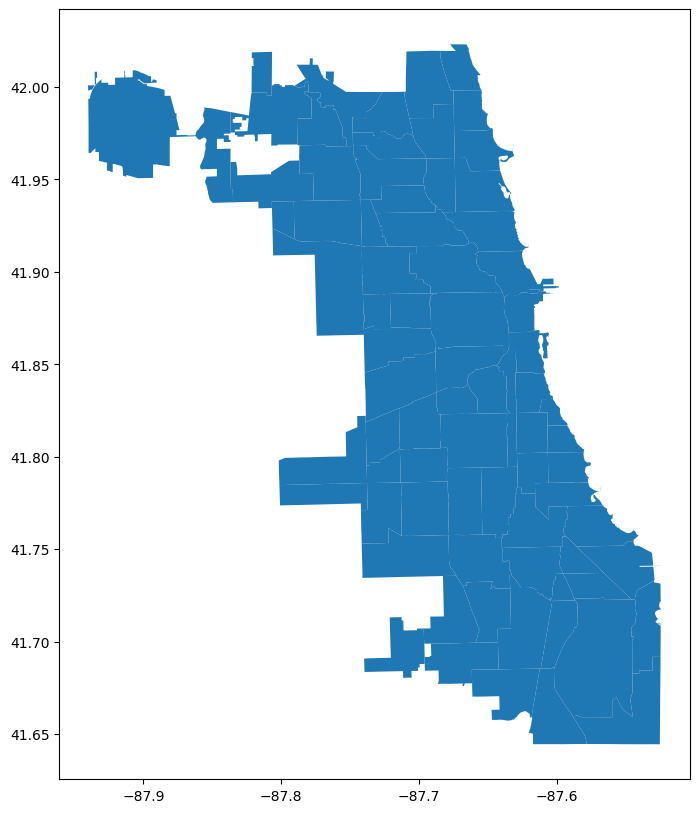

In [99]:
geometry = gpd.points_from_xy(clinics["longitude"], clinics["latitude"])

gdf = gpd.GeoDataFrame(
    clinics,
    geometry=geometry,
    crs="EPSG:4326"
)
gdf = gdf[
    (gdf["longitude"] > -89) &
    (gdf["longitude"] < -87) &
    (gdf["latitude"] > 41) &
    (gdf["latitude"] < 42.5)
]
community_areas = gpd.read_file(
    "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"
)
community_areas.plot(figsize=(10,10))

<Axes: >

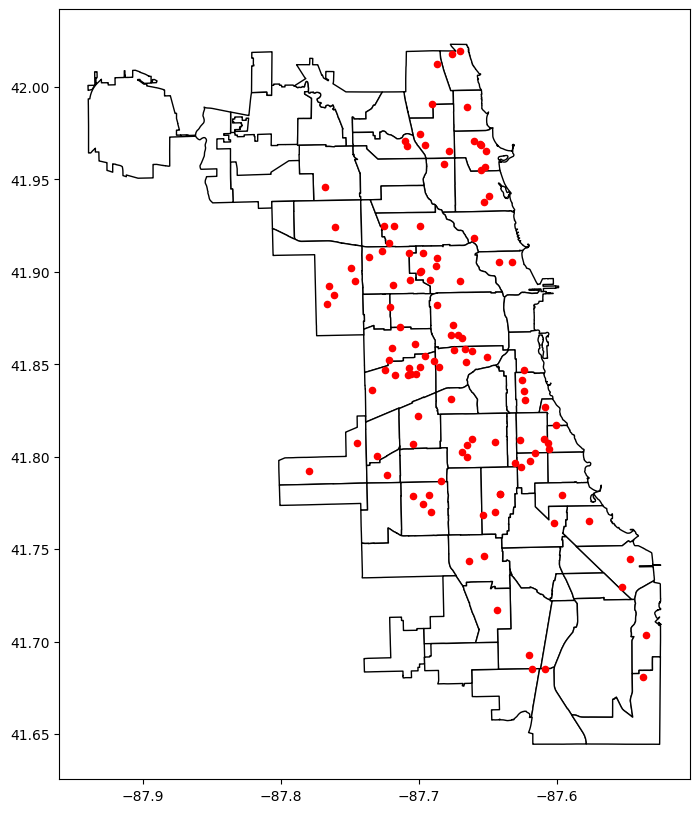

In [100]:
ax = community_areas.plot(
    figsize=(10,10),
    color="white",
    edgecolor="black"
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=20
)

##Research Question 1: Are community health clinics distributed according to neighborhood need across Chicago?

Previous research has found that community health resources in Chicago are unevenly distributed across neighborhoods. Kim et al. argue that “not all disadvantaged neighborhoods equally benefit from such programs.” This project explores whether community health clinic locations in Chicago appear to align with neighborhood socioeconomic need, particularly poverty levels and racial composition. Using census demographic data and geospatial mapping, this analysis investigates whether clinics are concentrated in the neighborhoods with the greatest disadvantage or whether some high-need areas remain underserved.

In [101]:
c = Census("54240400e7f28af6d8247ba6ad58f9b60cf1e345")
acs = c.acs5.state_county_tract(
    fields = (
        'NAME',
        'B19013_001E',
        'B17001_002E',
        'B01003_001E',
        'B02001_003E',
        'B02001_002E',
        'B03003_003E'
    ),
    state_fips=states.IL.fips,
    county_fips='031',
    tract='*',
    year=2022
)

acs_df = pd.DataFrame(acs)
acs_df = acs_df.rename(columns={
    "B19013_001E": "median_income",
    "B17001_002E": "poverty_population",
    "B01003_001E": "total_population",
    "B02001_003E": "black_population",
    "B02001_002E": "white_population",
    "B03003_003E": "hispanic_population"
})

acs_df["pct_black"] = (
    acs_df["black_population"] /
    acs_df["total_population"]
) * 100

acs_df["pct_poverty"] = (
    acs_df["poverty_population"] /
    acs_df["total_population"]
) * 100

acs_df["pct_hispanic"] = (
    acs_df["hispanic_population"] /
    acs_df["total_population"]
) * 100

acs_df["GEOID"] = (
    acs_df["state"] +
    acs_df["county"] +
    acs_df["tract"]
)
tracts = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_17_tract.zip"
)
tracts = tracts[
    tracts["COUNTYFP"] == "031"
]
tracts = tracts.merge(
    acs_df,
    on="GEOID",
    how="left"
)

In [102]:
community_areas = gpd.read_file(
    "https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/master/data/chicago-community-areas.geojson"
)
tracts = tracts.to_crs(community_areas.crs)
tracts_joined = gpd.sjoin(
    tracts,
    community_areas,
    predicate="intersects"
)
community_demo = (
    tracts_joined
    .groupby("community")
    .agg({
        "total_population": "sum",
        "black_population": "sum",
        "hispanic_population": "sum",
        "poverty_population": "sum"
    })
    .reset_index()
)
community_demo["pct_black"] = (
    community_demo["black_population"] /
    community_demo["total_population"]
) * 100

community_demo["pct_hispanic"] = (
    community_demo["hispanic_population"] /
    community_demo["total_population"]
) * 100

community_demo["pct_poverty"] = (
    community_demo["poverty_population"] /
    community_demo["total_population"]
) * 100
clinic_counts = (
    gdf.groupby("community_area_name")
    .size()
    .reset_index(name="clinic_count")
)
final = community_demo.merge(
    clinic_counts,
    left_on="community",
    right_on="community_area_name",
    how="left"
)
community_areas = community_areas.merge(
    final,
    on="community",
    how="left"
)

(np.float64(-87.96091293145491),
 np.float64(-87.50333825496381),
 np.float64(41.625618348273974),
 np.float64(42.041963359379665))

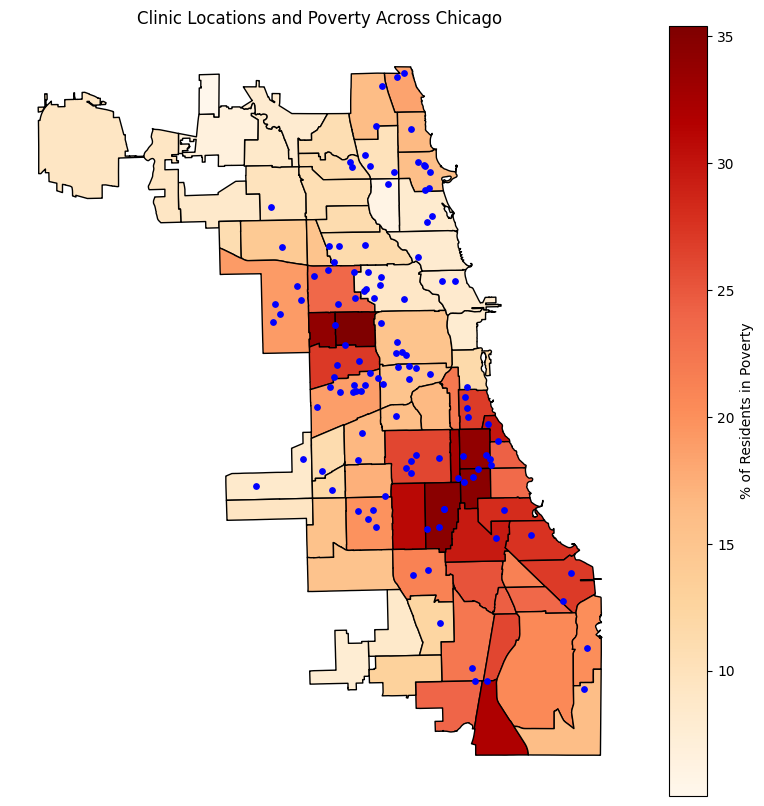

In [104]:
ax = community_areas.plot(
    column="pct_poverty",
    cmap="OrRd",
    legend=True,
    figsize=(10,10),
    edgecolor="black",
    legend_kwds={"label": "% of Residents in Poverty"}
)

gdf.plot(
    ax=ax,
    color="blue",
    markersize=15
)

plt.title("Clinic Locations and Poverty Across Chicago")
plt.axis("off")

The spatial distribution of clinics appears related to neighborhood poverty levels. Higher-poverty areas on Chicago’s South and West sides generally contain greater concentrations of community health clinics. However, the relationship is not perfectly proportional, as several high-poverty neighborhoods still appear to have relatively limited clinic access compared to surrounding areas.

Although census tracts provide more spatially detailed demographic information, the clinic dataset was organized by Chicago community areas. To ensure that the geographic units aligned across datasets, tract-level ACS demographic data were aggregated to the community-area level before analysis. This allowed clinic counts and neighborhood demographic characteristics to be compared consistently across the same spatial units.

## Research Question 2: Which Chicago neighborhoods appear underserved by community health clinics despite high levels of disadvantage?

##References

Kim, Y., Byon, H. D., & Yeo, E. (2021). The uneven distribution of medically underserved areas and community health centers in Chicago. Preventive Medicine Reports, 22, 101406. https://doi.org/10.1016/j.pmedr.2021.101406